# Negative Triangularity Analysis

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real
from tqdm.notebook import tqdm

In [132]:
# %% Load my own libraries
%load_ext autoreload
%autoreload 2
from c1lgkt.jax.fields.equilibrium import Equilibrium
from c1lgkt.jax.fields.clebsch import ClebschMappingBuilder
from c1lgkt.jax.fields.field_providers import EikonalFieldProvider, ZonalFieldProvider
import c1lgkt.jax.particles.particle_motion as particle_motion
import c1lgkt.jax.particles.particle_tools as particle_tools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# %% Load equilibrium and set up clebsch mapping
eq = Equilibrium.from_gfile('./scratch/data/g193802.04490')

clebsch_builder = ClebschMappingBuilder()
# Check if the mapping file exists
if os.path.isfile('./scratch/outputs/theta_map_193802.eqx'):
    print('Loading existing theta map...')
    theta_map = clebsch_builder.load_theta_map('./scratch/outputs/theta_map_193802.eqx')
else:
    print('Building new theta map...')
    theta_map = clebsch_builder.build_theta_map(eq)
    eqx.tree_serialise_leaves('./scratch/outputs/theta_map_193802.eqx', theta_map)
# Build Clebsch representation
if os.path.isfile('./scratch/outputs/clebsch_193802.eqx'):
    print('Loading existing Clebsch representation...')
    clebsch = clebsch_builder.load_clebsch('./scratch/outputs/clebsch_193802.eqx')
else:
    print('Building new Clebsch representation...')
    clebsch = clebsch_builder.build_clebsch(theta_map, eq)
    eqx.tree_serialise_leaves('./scratch/outputs/clebsch_193802.eqx', clebsch)

Loading existing theta map...
Loading existing Clebsch representation...


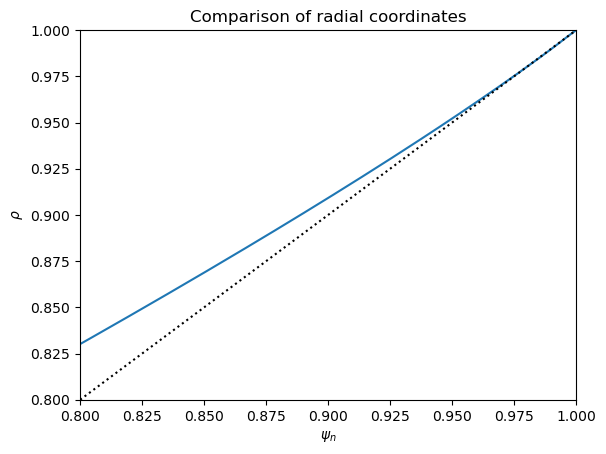

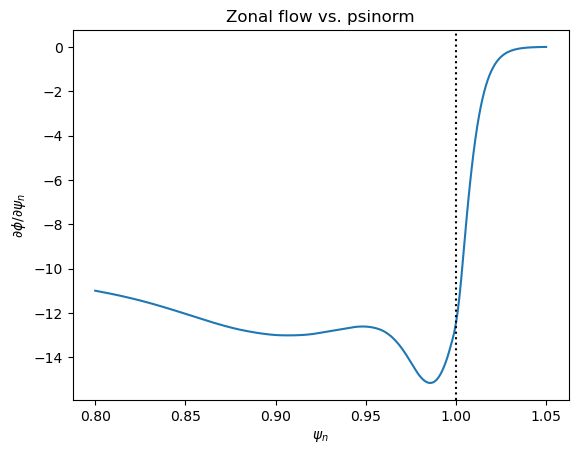

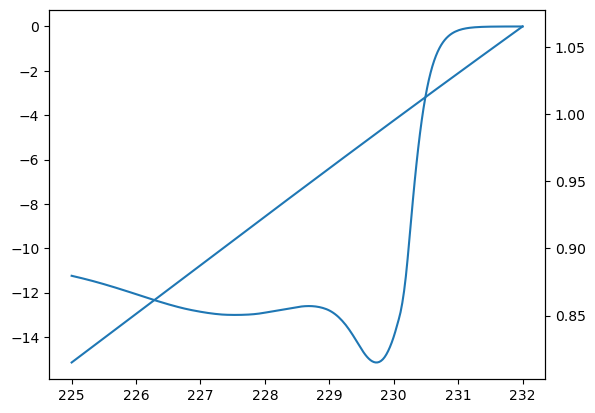

In [5]:
# %% Set up fields

# Load Er from pfile
zonal_fields = ZonalFieldProvider.from_pfile('./scratch/data/p193802.04490', eq)

# Compute the toroidal flux coordinate for comparison with stewart et al.
psinorm = np.linspace(0.0, 1.0, 256)
mids = (psinorm[1:] + psinorm[:-1]) * 0.5
# Use midpoint rule to compute the toroidal flux
q_clebsch = (clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, jnp.pi)) - clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, -jnp.pi))) / (2 * jnp.pi)
torflux = np.concatenate([np.array([0.0]), np.cumsum(q_clebsch)])
rhonorm = np.sqrt(torflux / torflux[-1])

plt.figure()
plt.plot(psinorm, rhonorm)
plt.plot([0.8, 1.0], [0.8, 1.0], ls=':', c='k')
plt.xlim(0.8, 1.0)
plt.ylim(0.8, 1.0)
plt.title('Comparison of radial coordinates')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\rho$')


plt.figure()
psi_plot = jnp.linspace(eq.psix*0.8, eq.psix*1.05, 256)
phi_plot = zonal_fields.interp_phi(psi_plot, dx=1)
plt.plot(psi_plot/eq.psix, phi_plot)
plt.axvline(1.0, ls=':', c='k')
plt.title('Zonal flow vs. psinorm')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\partial\phi / \partial \psi_n$')

plt.figure()
r_plot = jnp.linspace(2.25, 2.32, 256)
psi_plot_2 = eq.interp_psi(r_plot, jnp.full_like(r_plot, eq.zaxis))
plt.plot(r_plot * 100, zonal_fields.interp_phi(psi_plot_2, dx=1))
plt.twinx()
plt.plot(r_plot * 100, psi_plot_2/eq.psix)


In [94]:
coefs = jnp.zeros((1, 4, 6))
# Te ~ 0.25 keV at rho ~ 0.95. We want e phi / Te ~ ntilde / n0 ~ 3e-2; phi is in kV
# This ends up being around 7.5 V
coefs = coefs.at[0, 0, 0].set(0.25*3e-2)

eikonal_field = EikonalFieldProvider(
    theta_map,
    clebsch,
    # n = 7 leads to k_\theta of about 0.176 rad/cm at the OMP
    jnp.array([7], dtype=int),
    # taking f about 20 kHz
    jnp.array([2*jnp.pi*20.0]),
    # Perturbation is centered around rho = 0.95
    jnp.array([0.95*eq.psix]),
    # Width is about 0.05 in normalized psi
    jnp.array([0.05*eq.psix]),
    # Mode is peaked at the outer midplane
    jnp.array([0.0]),
    # Poloidal extent of the mode; somewhat arbitrary for now
    jnp.array([jnp.pi]),
    # Amplitude of the mode; see earlier
    coefs
    )

8.924979129516458 2.5


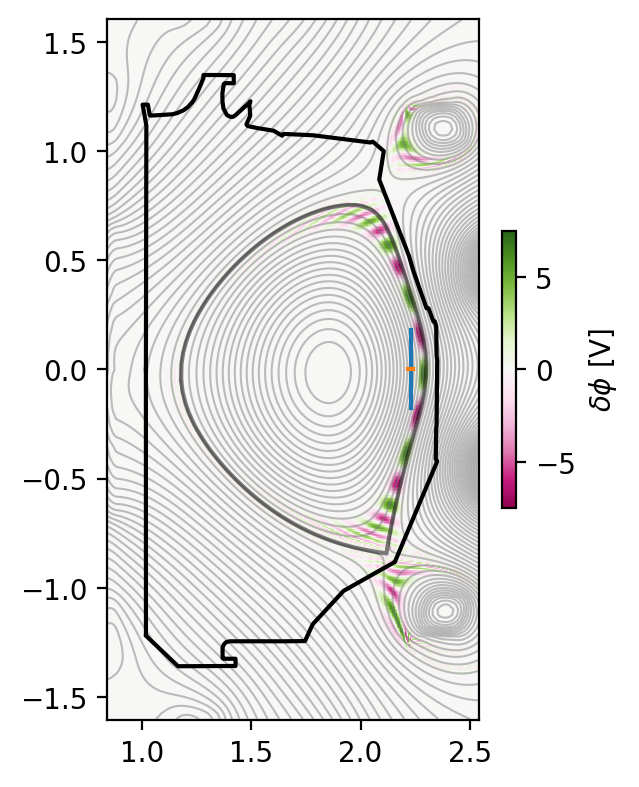

In [ ]:
# %% Plot the equilibrium and the Clebsch representation
fig = plt.figure(figsize=(3, 6), dpi=200)

ax = plt.subplot(111)

eq.plot_magnetic_geometry(ax, alpha=0.5)

rgrid = np.linspace(eq.rmin, eq.rmax, 512)
zgrid = np.linspace(eq.zmin, eq.zmax, 512)
rplot, zplot = np.meshgrid(rgrid, zgrid, indexing='ij')

theta = theta_map(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)
psi = eq.interp_psi(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)

alpha = clebsch.interp_alpha(psi.ravel(), theta.ravel()).reshape(psi.shape)

psi_ev, ff_ev = eq.compute_psi_and_ff(rplot.ravel(), zplot.ravel())
phi_fluct, apar_fluct = eikonal_field(0.0, rplot.ravel(), jnp.zeros_like(rplot.ravel()), zplot.ravel(), psi_ev)

phi_max = jnp.max(jnp.abs(phi_fluct))*1e3

pc = ax.pcolormesh(rplot, zplot, phi_fluct.reshape(psi.shape)*1e3, shading='auto', cmap='PiYG', vmin=-phi_max, vmax=phi_max)
plt.colorbar(pc, label=R'$\delta\phi$ [V]', shrink=0.3)

## From Stewart+ PPCF 2025 fig. 4, this is maybe the right poloidal wavelength on the OMP
l_poloidal = (2 * jnp.pi / 0.176) / 100.0
l_radial = 2.5 / 100.0
print((l_poloidal/4)*100, l_radial*100)
ax.plot([2.23, 2.23], [-l_poloidal/2, l_poloidal/2])
ax.plot([2.23-l_radial/2, 2.23+l_radial/2], [0.0, 0.0])

In [95]:
# Set up interpolator for r(psi) so we can initialize particles in psi space
r_outer = jnp.linspace(eq.raxis, eq.rmax, 128)
psi_outer = eq.interp_psi(r_outer, jnp.full_like(r_outer, eq.zaxis))
interp_router = interpax.Interpolator1D(psi_outer, r_outer, method='cubic2')

# reference position
r_ref = interp_router(0.95*eq.psix)
z_ref = eq.zaxis
bv = eq.compute_bv(jnp.array([r_ref]), jnp.array([z_ref]))
modb = jnp.linalg.norm(bv)

# Electrons 
pp = particle_motion.elec
# Reference kinetic energy of particles ~ Te ~ 0.25 keV
ev_ref = 0.25
# cos(pitch angle) ~ 0.33
xi_ref = jnp.sqrt(0.33)
# Initial parallel velocity
upar_ref = pp.vt * xi_ref * np.sqrt(ev_ref)
# Initial magnetic moment
mu_ref = pp.m * (1-xi_ref**2) * (pp.vt * np.sqrt(ev_ref))**2 / 2 / modb

# Set up the reference state
t0 = 0.0
state_ref = (
    jnp.array([r_ref]),
    jnp.array([0.0]),
    jnp.array([z_ref]),
    jnp.array([upar_ref]),
    jnp.array([mu_ref]),
)

# Set up the PusherArgs
args = particle_motion.PusherArgs(
    eq=eq,
    pp=pp,
    fields=[zonal_fields, eikonal_field]
)

# Compute the integrals of motion for the reference state
ham_ref, lphi_ref = particle_tools.compute_integrals(t0, state_ref, args)
# Unpack the reference integrals
ham_ref = ham_ref[0]
lphi_ref = lphi_ref[0]

In [ ]:
# %% Set up initial conditions

# Number of particles
nump = 48

# Initial positions: evenly spaced in varphi, and in a narrow range of psi around 0.95
varphi0 = jnp.linspace(0, 2*jnp.pi/7, nump, endpoint=False)
r0 = interp_router(jnp.linspace(0.945*eq.psix, 0.955*eq.psix, nump))
#r0 = jnp.full_like(varphi0, r_ref)
z0 = jnp.full_like(r0, eq.zaxis)
mu0 = jnp.full_like(r0, mu_ref)

# Set up the initial partial state tuple
y0 = (
    r0,
    varphi0,
    z0,
    jnp.full_like(r0, upar_ref),
    mu0
)

# Compute the parallel kinetic energies
omega_frame = eikonal_field.omega[0] / eikonal_field.n[0]

# Get the parallel kinetic energy
kpar, upar_omega = particle_tools.compute_parallel_energy(t0, y0, (ham_ref, lphi_ref), omega_frame, args)

upar0 = jnp.sqrt(2 * kpar / pp.m) + upar_omega

y0 = (
    r0,
    varphi0,
    z0,
    upar0,
    mu0
)

# Set up ODE
term = diffrax.ODETerm(particle_motion.f_driftkinetic)
solver = diffrax.Dopri5()
saveat = diffrax.SaveAt(t0=True, t1=True, steps=True)
stepsize_controller = diffrax.PIDController(rtol=1e-8, atol=1e-8)

# Test f_driftkinetic
dy0 = particle_motion.f_driftkinetic(t0, y0, args)

In [ ]:
# %% Integrate particle trajectories in blocks and compute punctures

import pickle

num_blocks = 48*96
ppuncs = [particle_tools.PunctureData(
    tp = np.zeros((0,)),
    yp = jax.tree.map(lambda x: np.zeros((0,)), y0)
)] * y0[0].shape[0]
npuncs = [particle_tools.PunctureData(
    tp = np.zeros((0,)),
    yp = jax.tree.map(lambda x: np.zeros((0,)), y0)
)] * y0[0].shape[0]


for i in tqdm(range(num_blocks)):
    # Integrate particle trajectories
    sol = diffrax.diffeqsolve(
        term, solver, t0=t0, t1=10000.0, dt0=2e-6, y0=y0,
        args=args, stepsize_controller=diffrax.ConstantStepSize(), saveat=saveat,
        max_steps=4096,
        throw=False
    )

    # Extract solution and compute punctures
    r_sol, varphi_sol, z_sol, vpar_sol, mu_sol = sol.ys # pyright: ignore
    #phase = eikonal_field.n[0]*varphi_sol - (sol.ts*eikonal_field.omega[0])[:,None] # pyright: ignore
    #ppuncs_i, npuncs_i = particle_tools.compute_punctures(sol.ts, sol.ys, phase, period=2*jnp.pi) # pyright: ignore
    ppuncs_i, npuncs_i = particle_tools.compute_punctures(sol.ts, sol.ys, z_sol - eq.zaxis) # pyright: ignore

    # Accumulate punctures
    ppuncs = jax.tree.map(lambda *xs: jnp.concatenate(xs), ppuncs, ppuncs_i)
    npuncs = jax.tree.map(lambda *xs: jnp.concatenate(xs), npuncs, npuncs_i)

    # Update initial conditions for next block
    t0 = sol.ts[-1] # pyright: ignore
    y0 = (
        r_sol[-1],
        varphi_sol[-1],
        z_sol[-1],
        vpar_sol[-1],
        mu_sol[-1]
    )


    if i%16 == 0:
        with open('./scratch/outputs/puncs.pkl', 'wb') as f:
            pickle.dump((ppuncs, npuncs), f)


  0%|          | 0/48 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [189]:
npuncs

[PunctureData(tp=Array([0.30622639, 0.33048646, 0.35487153, 0.37913819, 0.4028249 ,
        0.42661726, 0.45093457, 0.47532233, 0.49950265, 0.52311968,
        0.54703249, 0.57138493, 0.59577094, 0.61984332, 0.64343141,
        0.66746638], dtype=float64), yp=(Array([2.28555347, 2.28568502, 2.28568828, 2.28556243, 2.28550492,
        2.28557387, 2.28570485, 2.28566499, 2.28554359, 2.28550905,
        2.28559739, 2.28571654, 2.28563936, 2.28552784, 2.28551766,
        2.28562339], dtype=float64), Array([-0.13374771, -0.41482064, -0.69753932, -0.97885608, -1.25274506,
        -1.52786723, -1.80967556, -2.09245226, -2.37266974, -2.64565412,
        -2.92229835, -3.2045603 , -3.48734078, -3.76617851, -4.03877302,
        -4.31696908], dtype=float64), Array([-0.01425976, -0.01425976, -0.01425976, -0.01425976, -0.01425976,
        -0.01425976, -0.01425976, -0.01425976, -0.01425976, -0.01425976,
        -0.01425976, -0.01425976, -0.01425976, -0.01425976, -0.01425976,
        -0.01425976], dty

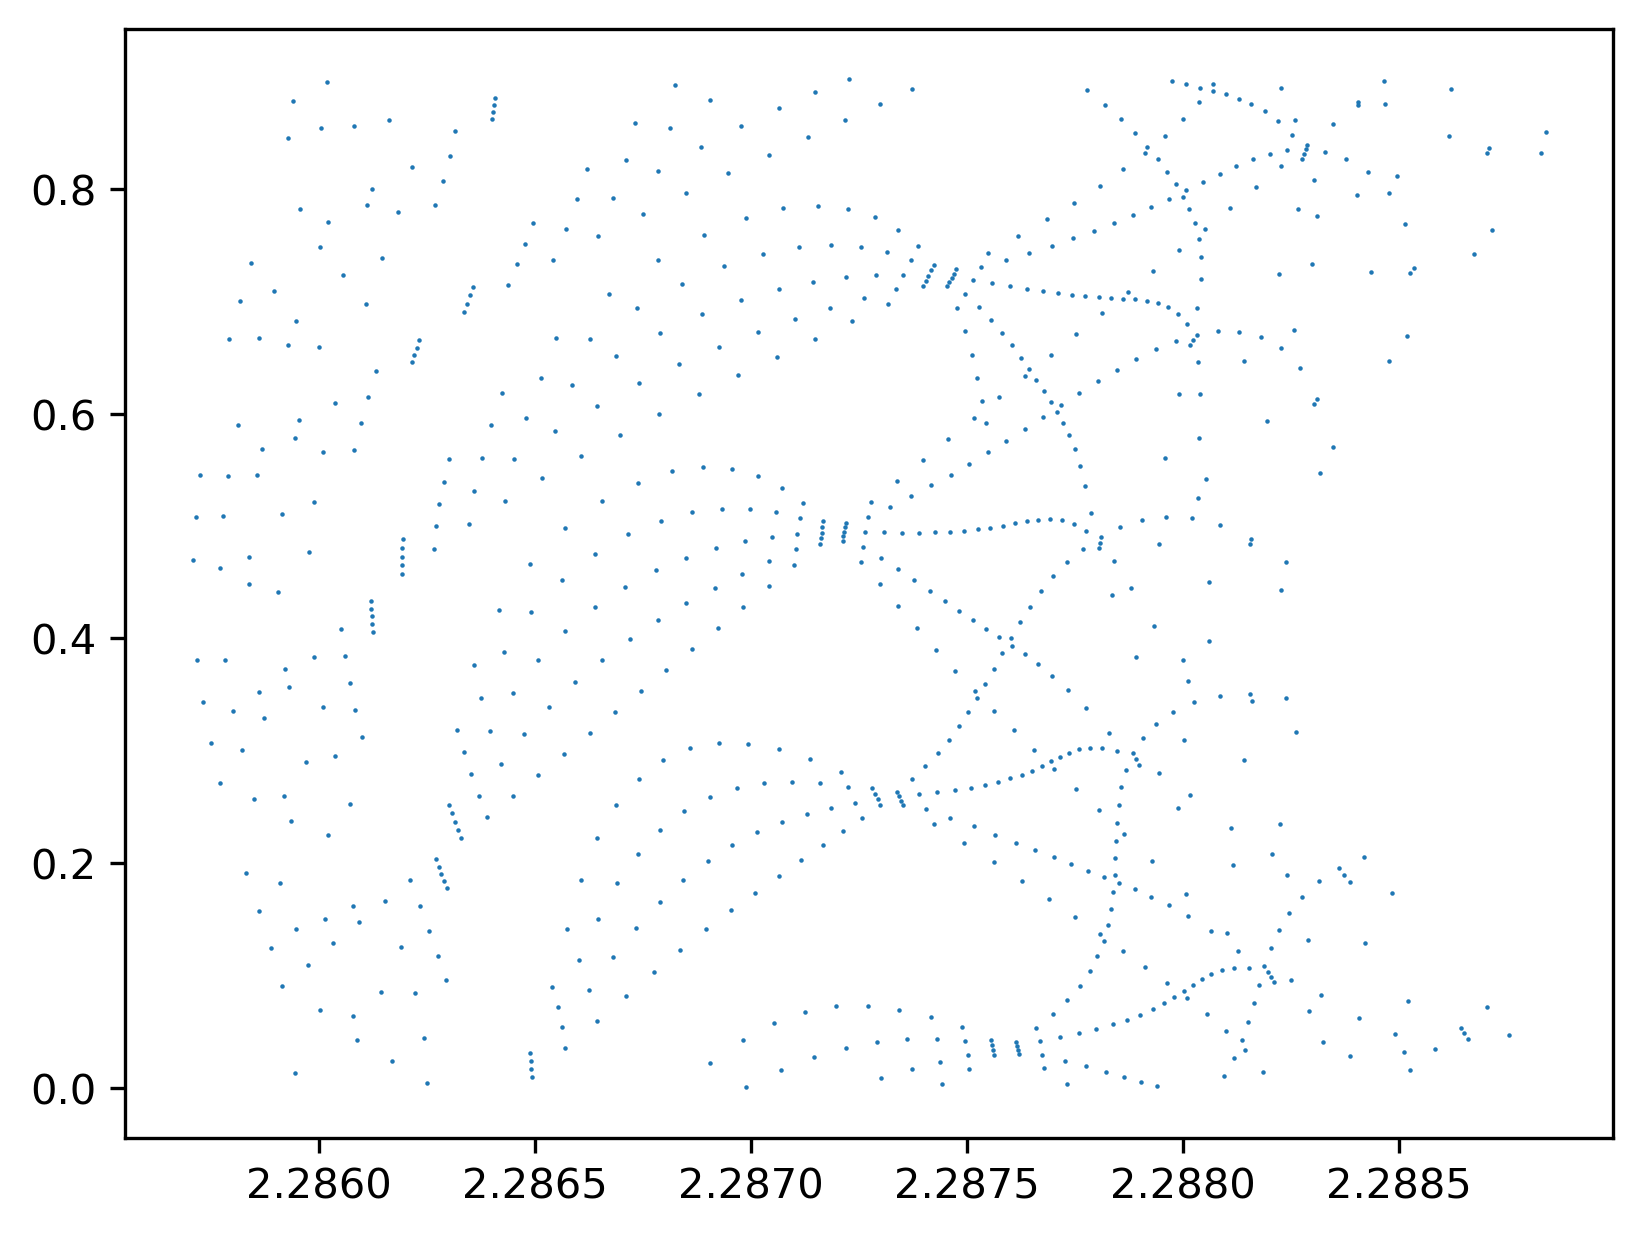

In [187]:
# %% Plot punctures colored by digits of accuracy computed via WBA
import matplotlib as mpl

plt.figure(dpi=300)

ax = plt.subplot(111)
#eq.plot_magnetic_geometry(ax, alpha=0.2)
for k in range(r_sol.shape[1]):
    punc = ppuncs[k]
    r_p, varphi_p, z_p, vll_p, mu_p = punc.yp
    phase = eikonal_field.n[0]*varphi_p - (punc.tp*eikonal_field.omega[0]) # pyright: ignore
    #psi_p = eq.interp_psi(r_p, z_p)

    plt.scatter(r_p, np.mod(phase, 2*np.pi)/eikonal_field.n[0], s=9.0*(72/100.0)**2, lw=0.0, marker='.', color='tab:blue')

In [180]:
phase

Array([-14.436456  , -20.23357066, -25.87324453, -31.49728649,
       -37.41758915], dtype=float64)

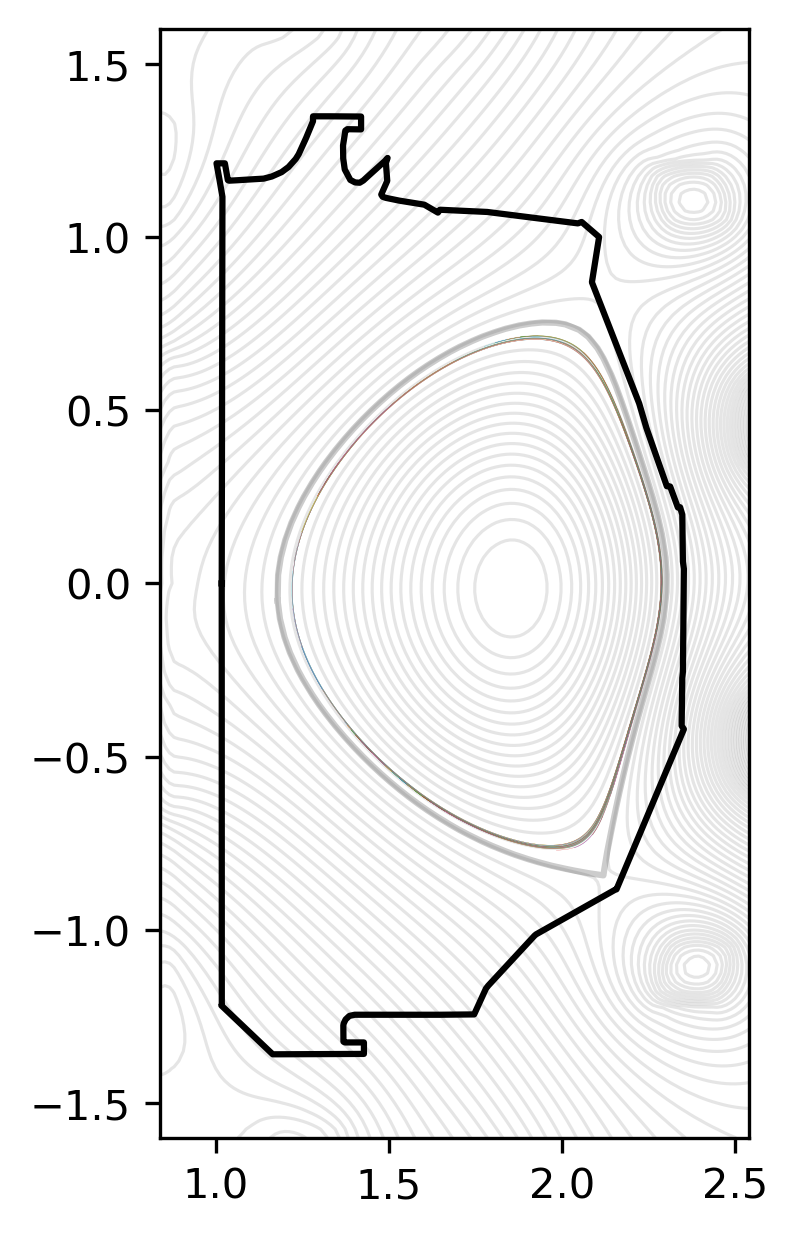

In [172]:
# %% Diagnostic plots

# Plot the last block of trajectories in (r, z) space
plt.figure(dpi=300)
ax = plt.subplot(111)
eq.plot_magnetic_geometry(ax, alpha=0.2)
plt.plot(r_sol, z_sol, lw=0.05)

In [160]:
# Check the value of H - Omega * Lphi
plt.figure()
ts = np.zeros(r_sol.shape[0])
ts[:] = sol.ts
hams = np.empty(r_sol.shape)
lphis = np.empty(r_sol.shape)

for i in range(ts.shape[0]):
    hams[i], lphis[i] = particle_tools.compute_integrals(ts[i], jtu.tree_map(lambda x: x[i], sol.ys), args)


<Figure size 640x480 with 0 Axes>

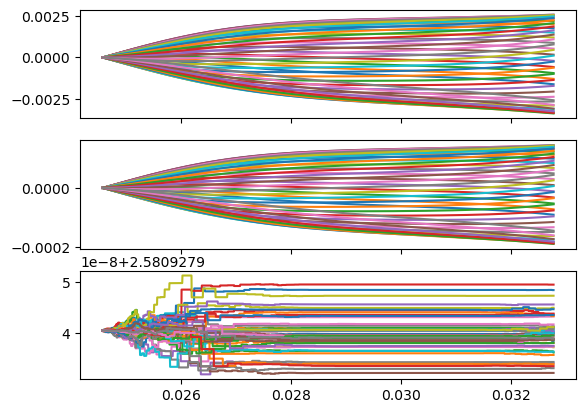

In [195]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, sharex=True)

for k in range(r_sol.shape[1]):
    axs[0].plot(ts, hams[:,k] - hams[0,k])
    axs[1].plot(ts, (lphis[:,k] - lphis[0,k]))
    omega_frame = eikonal_field.omega[0] / eikonal_field.n[0]
    axs[2].plot(ts, hams[:,k] - omega_frame * lphis[:,k])